<div style="text-align: right">Author: Yuktha Bhadane (yb294@cornell.edu)</div>

### Global Spatial Distribution of Fossil Fuel Power Plants
This notebook visualizes the spatial distribution of fossil fuel power plants globally, categorized by fuel type (Coal, Gas, Oil) with markers sized according to capacity

0. Set up

In [1]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

1. Data Loading and Processing

In [2]:
def load_power_plant_data(path):
    """
    Load power plant data from CSV and filter for operating fossil fuel plants.
    
    Parameters:
    path (str): Path to power plant CSV file
    
    Returns:
    pandas.DataFrame: Filtered dataframe with fossil fuel plants
    """
    df = pd.read_csv(path)
    
    # Filter only operating fossil fuel plants
    fossil_plants = df[
        (df['status'] == 'operating') & 
        (df['subsector'].isin(['Coal', 'Oil', 'Gas']))
    ].copy()
    
    # Convert emissions from Mt to Gt for better readability
    fossil_plants['annual_co2_calc_gt'] = fossil_plants['annualco2tyear'] / 1000
    
    return fossil_plants

def calculate_country_emissions(plants_df):
    """
    Calculate total emissions by country.
    
    Parameters:
    plants_df (pandas.DataFrame): Dataframe with power plant data
    
    Returns:
    pandas.DataFrame: Dataframe with country-level emissions
    """
    country_emissions = plants_df.groupby('countryiso3')['annual_co2_calc_gt'].sum().reset_index()
    return country_emissions

def load_world_map(country_emissions):
    """
    Load world map and merge with emissions data.
    
    Parameters:
    country_emissions (pandas.DataFrame): Country-level emissions data
    
    Returns:
    geopandas.GeoDataFrame: World map with emissions data
    """
    # Load natural earth world map
    world = gpd.read_file("https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip")
    
    # Merge emissions data with world map
    world = world.merge(country_emissions, how='left', left_on='ISO_A3', right_on='countryiso3')
    
    return world

2. Visualization


In [3]:
def create_global_plant_map(world_gdf, plants_df):
    """
    Create a visualization of global fossil fuel power plants.
    
    Parameters:
    world_gdf (geopandas.GeoDataFrame): World map with emissions data
    plants_df (pandas.DataFrame): Power plant data
    
    Returns:
    matplotlib.figure.Figure: Figure containing the visualization
    """
    # Create a mask for countries with missing data
    missing_data = world_gdf[world_gdf['annual_co2_calc_gt'].isna()]
    
    # Create figure and axes
    fig, ax = plt.subplots(figsize=(20, 8))
    ax.set_facecolor('#F0F8FF')  # Light blue background for oceans
    
    # Plot countries with data
    world_gdf[world_gdf['annual_co2_calc_gt'].notna()].plot(
        ax=ax, 
        color='white',
        edgecolor='black',
        linewidth=0.5
    )
    
    # Plot countries without data
    missing_data.plot(
        ax=ax,
        color='white',
        edgecolor='gray',
        linestyle=':',
        linewidth=1
    )
    
    # Create scatter plot of power plants
    scatter = plt.scatter(
        plants_df['longitude'],
        plants_df['latitude'],
        c=plants_df['subsector'].map({'Coal': 'red', 'Gas': 'orange', 'Oil': 'brown'}),
        s=plants_df['capacity']/20,  # Size based on capacity
        alpha=0.7
    )
    
    # Create legend for fuel types
    handles = [plt.scatter([], [], c=c, label=l) for l, c in zip(['Coal', 'Gas', 'Oil'], ['red', 'orange', 'brown'])]
    plt.legend(handles=handles, bbox_to_anchor=(0.35, 0.3), frameon=False, ncol=3, fontsize='14')
    
    # Add title and remove axis
    plt.title('Global Distribution of Fossil Fuel Power Plants', fontsize=16, pad=20)
    ax.axis('off')
    
    plt.tight_layout()
    return fig

3. Execution

/var/folders/n_/wz0dpmns379dn5s9v5qcpxww0000gn/T/ipykernel_92648/654716890.py:11: DtypeWarning: Columns (9,15,17,23,32,33) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path)


Saved plot to global_fossil_plant_spatial_map/global_fossil_plant_spatial_map.png


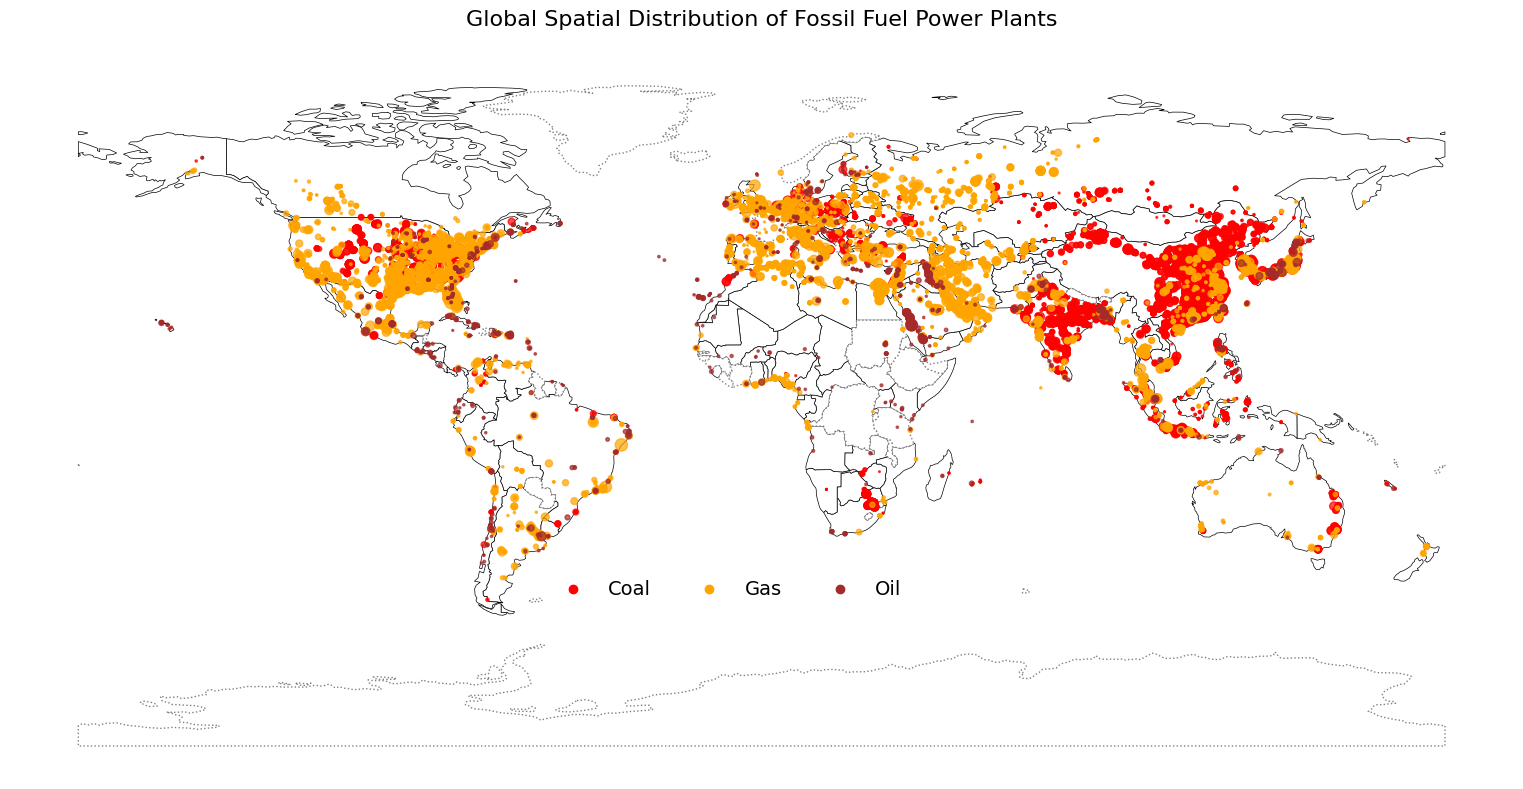

Saved plot to global_fossil_plant_spatial_map/global_fossil_plant_spatial_map.png


In [6]:
# Note: Update these paths to local or relative paths for GitHub
# Using absolute paths
data_path = "/Users/yukthabhadane/Documents/Climate Finance Thesis/Data/v3_power_Forward_Analytics2024.csv"

# Load and process data
fossil_plants = load_power_plant_data(data_path)
country_emissions = calculate_country_emissions(fossil_plants)
world = load_world_map(country_emissions)

# Create visualization
fig, ax = plt.subplots(figsize=(20, 8))
ax.set_facecolor('#F0F8FF')

# Plot countries with data
world[world['annual_co2_calc_gt'].notna()].plot(
    ax=ax, 
    color='white',
    edgecolor='black',
    linewidth=0.5
)

# Plot countries without data
missing_data = world[world['annual_co2_calc_gt'].isna()]
missing_data.plot(
    ax=ax,
    color='white',
    edgecolor='gray',
    linestyle=':',
    linewidth=1
)

# Plot power plants
scatter = plt.scatter(
    fossil_plants['longitude'],
    fossil_plants['latitude'],
    c=fossil_plants['subsector'].map({'Coal': 'red', 'Gas': 'orange', 'Oil': 'brown'}),
    s=fossil_plants['capacity']/20,
    alpha=0.7
)

# Add legend
handles = [plt.scatter([], [], c=c, label=l) for l, c in zip(['Coal', 'Gas', 'Oil'], ['red', 'orange', 'brown'])]
plt.legend(handles=handles, bbox_to_anchor=(0.35, 0.3), frameon=False, ncol=3, fontsize='14')

# Add title
plt.title('Global Spatial Distribution of Fossil Fuel Power Plants', fontsize=16, pad=20)

# Remove axis
ax.axis('off')
plt.tight_layout()

# Create output directory in the same location as this notebook
output_dir = Path("global_fossil_plant_spatial_map")
output_dir.mkdir(exist_ok=True, parents=True)

# Save the figure to the output directory
output_file = output_dir / "global_fossil_plant_spatial_map.png"
fig.savefig(output_file, bbox_inches='tight', dpi=300)
print(f"Saved plot to {output_file}")

# Display the plot
plt.show()

# Save the visualization
output_dir = Path("global_fossil_plant_spatial_map")
output_dir.mkdir(exist_ok=True, parents=True)
output_file = output_dir / "global_fossil_plant_spatial_map.png"
fig.savefig(output_file, bbox_inches='tight', dpi=300)
print(f"Saved plot to {output_file}")